In [1]:
using Revise
using Optics_in_the_length_gauge

In [2]:
using StaticArrays, Brillouin, Bravais, CairoMakie

const I2 = @SMatrix [1 0; 0 1]
const σs = [[0 1; 1 0], [0 -im; im 0], [1 0; 0 -1]]

3-element Vector{Matrix{Complex{Int64}}}:
 [0 + 0im 1 + 0im; 1 + 0im 0 + 0im]
 [0 + 0im 0 - 1im; 0 + 1im 0 + 0im]
 [1 + 0im 0 + 0im; 0 + 0im -1 + 0im]

In [4]:
two_Weyls_hamiltonian(μ, t, k; k0 = π/2) = -μ*I2 .+ 
    t[1]*sin(k[1]) .* σs[1] + t[2] * sin(k[2]) .* σs[2] + t[3] .* (cos(k[1]) - cos(k0)) .* σs[3]
two_Weyls_dh(t, k, a::Symbol) = two_Weyls_dh(t, k, symtoind(a))
two_Weyls_dh(t, k, a::Int) = ifelse(a == 3, 0 * I2, ifelse(a == 1, t[1]*cos(k[1]) .* σs[1] -   t[3]*sin(k[1]) .* σs[3], t[2] * cos(k[2]) .* σs[2]))

 function symtoind(a::Symbol)
    if     a == :x
        1
    elseif a == :y
        2
    elseif a == :z
        3
    end
end


symtoind (generic function with 1 method)

## Bands


2×2 SizedMatrix{2, 2, ComplexF64, 2, Matrix{ComplexF64}} with indices SOneTo(2)×SOneTo(2):
 0.540302+0.0im        0.841471-0.841471im
 0.841471+0.841471im  -0.540302+0.0im

In [5]:
using CairoMakie, BZpaths, LinearAlgebra

function bands(i, μ, ts, q)
    ϵs, ψs = eigen(two_Weyls_hamiltonian(μ,ts,q))   
    return ϵs[i]
end

function bs(μ; ts= [1,1,1], a = 1)
    # Rs = [[a, 0, 0], [0,a,0], [0, 0.0, a]]
    # sgnum = 32 # cube in 3d
    c = a 
    sgnum = 144 # 
    Rs = [[a, 0, 0], [-a/2, sqrt(3)*a/2, 0], [0, 0, c]]
    # Rs = [[a/2, sqrt(3)*a/2, 0], [-a/2, sqrt(3)*a/2, 0], [0, 0, c]]
    N = 200    #kpoints
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "E [eV]", title = "t1 = $(ts[1]) eV, t2 = $(ts[2]) eV, t3 = $(ts[3]) eV")
    for i in 1:2
        dispersion(q) = bands(i, μ, ts, q)
        BZpaths.plot_observable_in_kpath!(ax, dispersion, Rs, sgnum, N)#, high_sym_line high_sym_line = [:Γ, :M, :K, :Γ, :A, :L, :H, :A] )
    end
    fig
end

bs (generic function with 1 method)

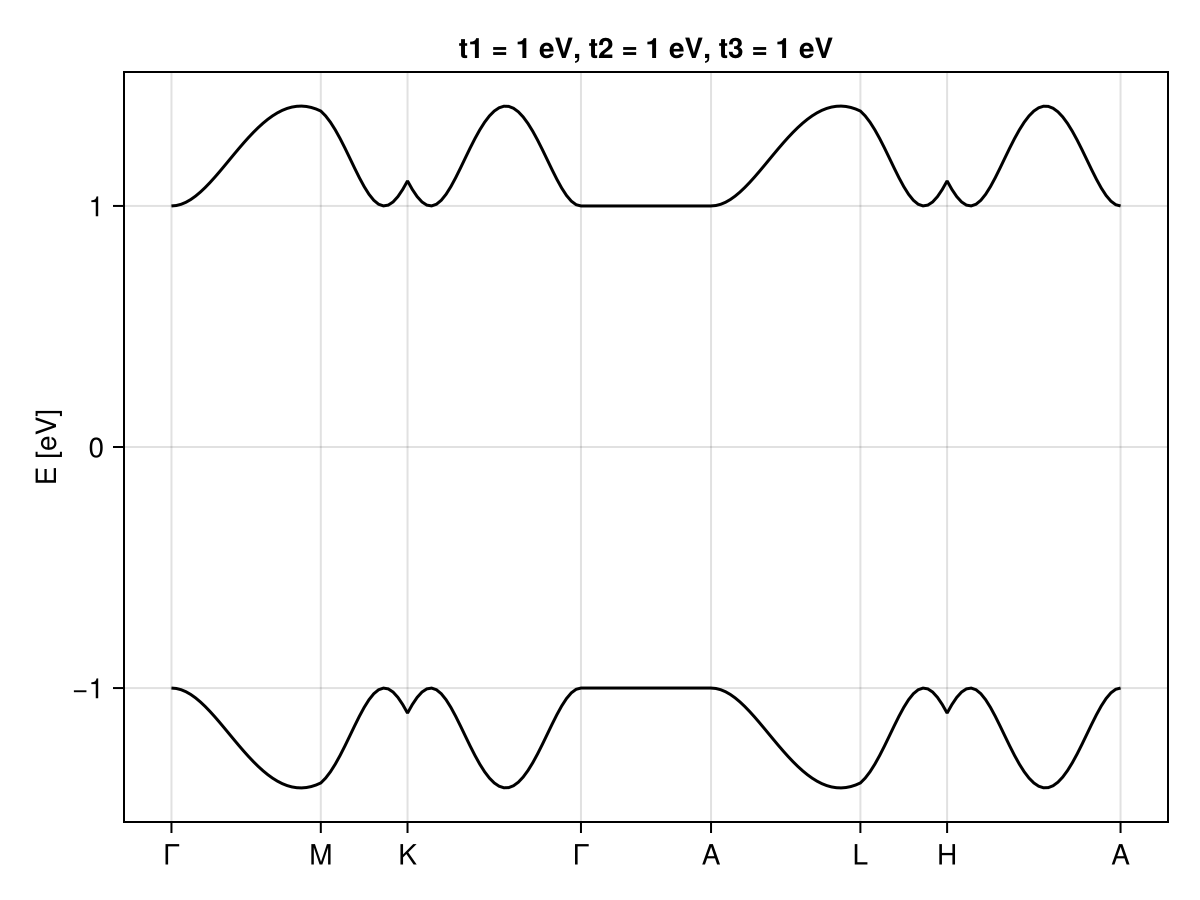

In [17]:
bs(0)

## AHE 

In [11]:
function ahe_3d_weyl(μ; ts = [0.0,0,0], dirj=:x, dirE=:y, T = 1,  evals = 100, 
    integration_method = :hcubature, botbounds = [-0.5,-0.5,-0.5], topbounds = [0.5,0.5,0.5])
    a = 1.0 # Å
    c = a 
    sgnum = 144 # 
    Rs = [[a, 0, 0], [-a/2, sqrt(3)*a/2, 0], [0, 0, c]]
    Gs = dualbasis(Rs)
    h(q) = two_Weyls_hamiltonian(μ, ts,q) #in 
    dhx(q) = two_Weyls_dh(ts,q, :x)
    dhy(q) = two_Weyls_dh(ts,q, :y)
    dhz(q) = two_Weyls_dh(ts,q, :z)
    dh(q) = [dhx(q), dhy(q), dhz(q)]
    computation = Transport_computation_3d_presets(botbounds,topbounds, evals, integration_method)
    return AH_presets_3d(a, dirj, dirE, h, dh, T, computation, Gs)
end



ahe_3d_weyl (generic function with 1 method)

In [12]:
ahe3dp = ahe_3d_weyl(0)

AH_presets_3d{SVector{3, Vector{Float64}}}
  a0: Float64 1.0
  dirJ: Symbol x
  dirE: Symbol y
  h: h (function of type var"#h#38"{Vector{Float64}, Int64})
  dh: dh (function of type var"#dh#42"{var"#dhz#41"{Vector{Float64}}, var"#dhy#40"{Vector{Float64}}, var"#dhx#39"{Vector{Float64}}})
  T: Float64 1.0
  computation: Transport_computation_3d_presets
  gs: SVector{3, Vector{Float64}}


In [19]:
σij_anomalous_hall(ahe3dp) 

Adaptive integration


0.0

In [ ]:
σij_anomalous_hall(ahe3dp) 